# L4 BMD Pipeline v4 — Stacked Hourglass Keypoint Detection

## 핵심 문제 & 해결

| 문제 | 원인 | 해결 |
|---|---|---|
| 척추 밖으로 midline 이탈 | 밝기 기반 DP → 어두운 척추 케이스 실패 | **Stacked Hourglass** 키포인트 예측 |
| 골반쪽으로 선이 그려짐 | 골반뼈가 척추보다 밝아서 최대값 오인 | 구조적 패턴 학습 → 밝기 독립 |

## 선정 모델: Stacked Hourglass Network

```
왜 Stacked Hourglass인가?
─────────────────────────────────────────────────────
1. 밝기 독립성: 픽셀 강도 직접 사용 X
   척추 주변 구조(돌기, 디스크 경계, 장골능)와의
   상대적 관계를 학습 → 어두운/밝은 척추 모두 처리

2. 다중 해상도: 전역(척추 전체 형태) + 국소(척추체 경계) 동시

3. 중간 감독(Intermediate Supervision):
   각 Hourglass 출력에 Loss → 안정적 학습

4. Gaussian Heatmap Regression:
   키포인트 위치를 확률 분포로 예측
   → sub-pixel 정밀도 가능

5. 의료 영상 SOTA: X-ray 척추 keypoint 논문에서 표준

아키텍처:
Input(256x256) → Pre-conv(64x64) → [HG1 → HM1 → HG2 → HM2]
출력: 9개 heatmap (L1~L5, Sacrum, IliacL, IliacR, SpineCenter)
```


## Step 0: 환경 설정

In [1]:
import subprocess, sys
def pip(p): subprocess.run([sys.executable,'-m','pip','install',p,'--break-system-packages','-q'],capture_output=True)
for p in ['pydicom','scikit-image','scipy','matplotlib','numpy',
          'pandas','tqdm','opencv-python-headless','scikit-learn',
          'nibabel']:
    pip(p)
pip('torch'); pip('torchvision')
print("packages ready")


packages ready


In [2]:
import os, glob, json, warnings, datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import pydicom, cv2
from tqdm import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from skimage import exposure, filters as sk_filters
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from sklearn.linear_model import LinearRegression

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
plt.rcParams['figure.dpi'] = 110


Device: cpu


## Step 1: 설정

In [3]:
DICOM_FILE = "./dataset-dcm/train/gather/1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm"
DATASET_ROOT = "./dataset"          # 많은 DICOM 파일이 있는 폴더
LABEL_CSV    = "./dataset/labels.csv"
OUTPUT_DIR   = "./bmd_v4_output"
MODEL_DIR    = os.path.join(OUTPUT_DIR, "models")
RESULT_DIR   = os.path.join(OUTPUT_DIR, "results")
LONGIT_DB    = os.path.join(OUTPUT_DIR, "longitudinal.json")
for d in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# Keypoint 정의
KP_NAMES  = ['SpineCenter','L1','L2','L3','L4','L5','Sacrum','IliacL','IliacR']
KP_L4_IDX = 4   # L4 keypoint index
N_KP      = len(KP_NAMES)

CFG = {
    'img_size'           : 256,
    'hm_size'            : 64,        # heatmap 해상도 (img_size/4)
    'hm_sigma'           : 3,         # 가우시안 sigma (heatmap 단위)
    'roi_size'           : 64,
    # Hourglass
    'hg_stacks'          : 2,
    'hg_ch'              : 128,
    # 훈련
    'batch_size'         : 8,
    'num_epochs'         : 80,
    'lr'                 : 1e-3,
    'weight_decay'       : 1e-4,
    'early_stop'         : 15,
    'train_ratio'        : 0.70,
    'val_ratio'          : 0.15,
    # Pseudo-label 생성
    'pseudo_confidence'  : 0.6,    # Hourglass confidence 임계값
    'pseudo_min_samples' : 5,      # 최소 pseudo-label 샘플 수
    # BMD calibration
    'muscle_offset'      : (25, 55),
    'muscle_rows_above'  : 30,
    'ref_young_mean'     : 19500.0,
    'ref_young_std'      : 1500.0,
    'ref_age_mean'       : 18500.0,
    'ref_age_std'        : 2000.0,
    # 척추 탐지 fallback
    'strip_width'        : 28,
    'iliac_search_y'     : (0.40, 0.60),
    'min_vert_dist'      : 12,
}
print(f"Keypoints: {KP_NAMES}")
print(f"L4 index: {KP_L4_IDX}")


Keypoints: ['SpineCenter', 'L1', 'L2', 'L3', 'L4', 'L5', 'Sacrum', 'IliacL', 'IliacR']
L4 index: 4


## Step 2: DICOM 로딩 & 전처리

Patient: 75 | 256x256


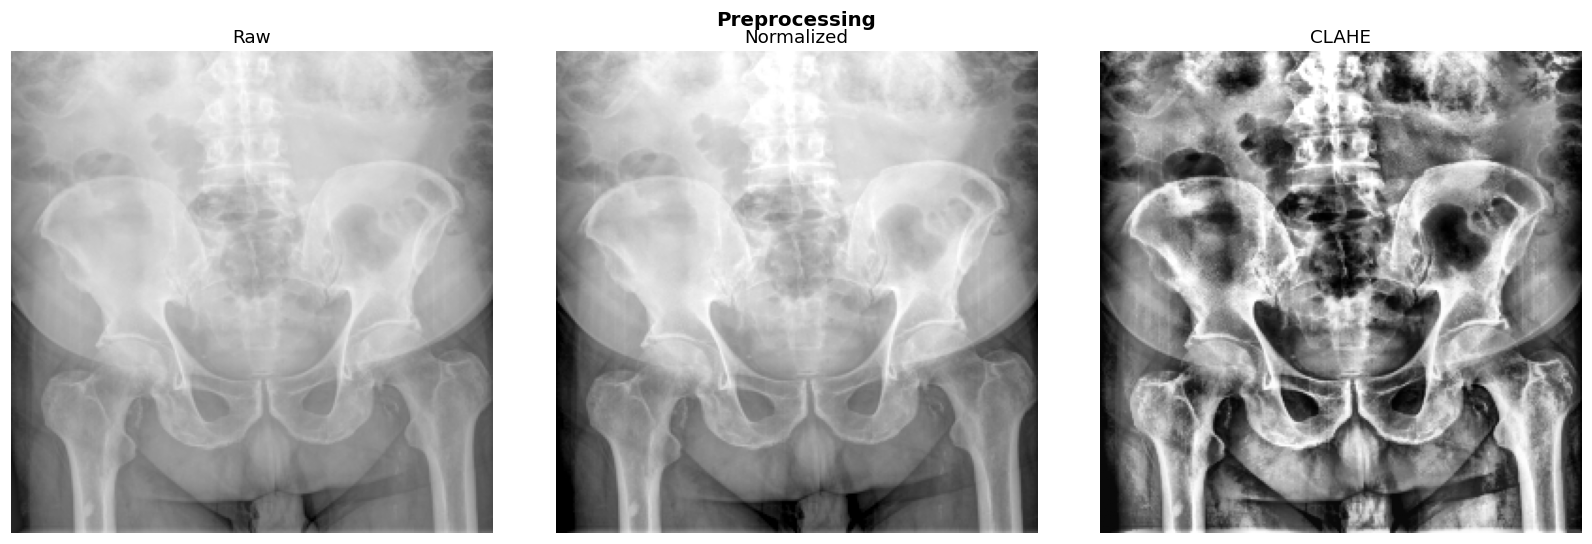

In [4]:
def load_dicom(path):
    dcm = pydicom.dcmread(path, force=True)
    arr = dcm.pixel_array.astype(np.float64)
    arr = arr*float(getattr(dcm,'RescaleSlope',1.0))+float(getattr(dcm,'RescaleIntercept',0.0))
    if str(getattr(dcm,'PhotometricInterpretation','MONOCHROME2')).strip()=='MONOCHROME1':
        arr = arr.max()-arr
    ps = list(getattr(dcm,'PixelSpacing',[0.1,0.1]))
    return arr, {
        'patient_id' : str(getattr(dcm,'PatientID',  'Unknown')),
        'patient_age': str(getattr(dcm,'PatientAge', 'Unknown')),
        'patient_sex': str(getattr(dcm,'PatientSex', 'Unknown')),
        'modality'   : str(getattr(dcm,'Modality',   'CR')),
        'study_date' : str(getattr(dcm,'StudyDate',  '')),
        'pixel_spacing': ps, 'shape': arr.shape,
        'filename'   : os.path.basename(path),
        'kvp'        : str(getattr(dcm,'KVP','Unknown')),
    }, dcm


def preprocess_xray(arr, size=256, clip=0.04):
    h,w=arr.shape; mx=max(h,w)
    pad=np.zeros((mx,mx),dtype=arr.dtype)
    yo,xo=(mx-h)//2,(mx-w)//2
    pad[yo:yo+h,xo:xo+w]=arr
    res=cv2.resize(pad,(size,size),interpolation=cv2.INTER_LINEAR)
    vmin,vmax=np.percentile(res,[1,99])
    norm=np.clip((res-vmin)/(vmax-vmin+1e-8),0,1).astype(np.float32)
    clahe=exposure.equalize_adapthist(norm,clip_limit=clip).astype(np.float32)
    return norm, clahe


arr, meta, dcm = load_dicom(DICOM_FILE)
norm, clahe    = preprocess_xray(arr)
h, w = clahe.shape
print(f"Patient: {meta['patient_id']} | {h}x{w}")

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(arr,cmap='gray'); axes[0].set_title('Raw'); axes[0].axis('off')
axes[1].imshow(norm,cmap='gray'); axes[1].set_title('Normalized'); axes[1].axis('off')
axes[2].imshow(clahe,cmap='gray'); axes[2].set_title('CLAHE'); axes[2].axis('off')
plt.suptitle('Preprocessing',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/01_preprocess.png',dpi=120,bbox_inches='tight')
plt.show()


## Step 3: Stacked Hourglass Network 정의

### 모델 구조
```
Input  (B, 1, 256, 256)
  │
  ├─ Pre-conv: stride=2, MaxPool → (B, 128, 64, 64)
  │
  ├─ Hourglass 1 (4-depth encoder-decoder)
  │    └─ Intermediate Heatmap 1 (B, 9, 64, 64)
  │         └─ re-inject back
  │
  └─ Hourglass 2 (4-depth encoder-decoder)
       └─ Final Heatmap (B, 9, 64, 64)

각 heatmap 채널: [SpineCenter, L1, L2, L3, L4★, L5, Sacrum, IliacL, IliacR]
L4 위치 = heatmap[4] 최대값의 (x,y) × 4 (img 좌표 복원)
```


In [5]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        half = max(ch//2, 1)
        self.net = nn.Sequential(
            nn.BatchNorm2d(ch), nn.ReLU(True), nn.Conv2d(ch, half, 1, bias=False),
            nn.BatchNorm2d(half), nn.ReLU(True), nn.Conv2d(half, half, 3, padding=1, bias=False),
            nn.BatchNorm2d(half), nn.ReLU(True), nn.Conv2d(half, ch, 1, bias=False))
    def forward(self, x): return self.net(x) + x


class Hourglass(nn.Module):
    """단일 Hourglass 모듈 (재귀 구조)"""
    def __init__(self, ch, depth=4):
        super().__init__()
        self.depth  = depth
        self.upper  = ResBlock(ch)
        self.pool   = nn.MaxPool2d(2, 2)
        self.lower1 = ResBlock(ch)
        self.lower2 = Hourglass(ch, depth-1) if depth > 1 else ResBlock(ch)
        self.lower3 = ResBlock(ch)
        self.up     = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        upper = self.upper(x)
        lower = self.pool(x)
        lower = self.lower1(lower)
        lower = self.lower2(lower)
        lower = self.lower3(lower)
        return upper + self.up(lower)


class StackedHourglass(nn.Module):
    """\n    Stacked Hourglass for Vertebra Keypoint Heatmap Regression\n\n    밝기 독립성의 핵심:\n    - ResBlock: 주변 구조와의 관계 패턴 학습\n    - Gaussian heatmap target: 절대 밝기 X, 상대적 위치 학습\n    - Intermediate supervision: 척추 전체 형태(전역) + 개별 척추체(국소) 동시\n\n    Keypoints (9개):\n        0: SpineCenter  1: L1  2: L2  3: L3\n        4: L4★          5: L5  6: Sacrum\n        7: IliacL       8: IliacR\n    """
    N_KP = 9

    def __init__(self, n_stacks=2, ch=128, n_kp=9):
        super().__init__()
        self.n_stacks = n_stacks
        self.n_kp     = n_kp

        # Pre-processing: 256 -> 64
        self.pre = nn.Sequential(
            nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            ResBlock(64),
            nn.MaxPool2d(2, 2),
            ResBlock(64), ResBlock(64),
            nn.Conv2d(64, ch, 1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(True))

        # Stacked modules
        self.hgs   = nn.ModuleList([Hourglass(ch) for _ in range(n_stacks)])
        self.feat  = nn.ModuleList([
            nn.Sequential(ResBlock(ch), nn.Conv2d(ch,ch,1,bias=False),
                          nn.BatchNorm2d(ch), nn.ReLU(True))
            for _ in range(n_stacks)])
        self.heads = nn.ModuleList([nn.Conv2d(ch, n_kp, 1) for _ in range(n_stacks)])

        # Re-injection (intermediate supervision)
        self.remap_feat = nn.ModuleList([nn.Conv2d(ch,  ch, 1) for _ in range(n_stacks-1)])
        self.remap_hm   = nn.ModuleList([nn.Conv2d(n_kp,ch, 1) for _ in range(n_stacks-1)])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        feat = self.pre(x)       # (B, ch, 64, 64)
        heatmaps = []
        for i in range(self.n_stacks):
            hg    = self.hgs[i](feat)
            feat2 = self.feat[i](hg)
            hm    = self.heads[i](feat2)
            heatmaps.append(hm)
            if i < self.n_stacks - 1:
                feat = feat + self.remap_feat[i](feat2) + self.remap_hm[i](hm)
        return heatmaps   # list of (B, N_KP, 64, 64)


# 모델 초기화
hg_model = StackedHourglass(
    n_stacks=CFG['hg_stacks'],
    ch=CFG['hg_ch'],
    n_kp=N_KP).to(DEVICE)

n_params = sum(p.numel() for p in hg_model.parameters())
print(f"StackedHourglass params: {n_params:,}")
_x = torch.randn(2,1,256,256).to(DEVICE)
_y = hg_model(_x)
print(f"Output: {len(_y)} stacks x {_y[0].shape}")
print(f"Keypoints: {KP_NAMES}")


StackedHourglass params: 1,611,090
Output: 2 stacks x torch.Size([2, 9, 64, 64])
Keypoints: ['SpineCenter', 'L1', 'L2', 'L3', 'L4', 'L5', 'Sacrum', 'IliacL', 'IliacR']


## Step 4: Pseudo-label 자동 생성

### 핵심 전략: Bootstrap Learning
```
Stage 1: 신뢰도 높은 케이스(밝은 척추) → heuristic으로 pseudo-label 생성
Stage 2: Stacked Hourglass 초기 학습 (pseudo-label 사용)
Stage 3: 학습된 모델로 어려운 케이스(어두운 척추) 예측
Stage 4: 수동 검수 후 데이터 추가 → 반복 개선

Pseudo-label 품질 판단 기준:
- iliac crest 선명도 (밝기 분산)
- 척추 vs 배경 대비비
- 대칭성 점수
```


In [6]:
def make_gaussian_heatmap(hm_h, hm_w, cx, cy, sigma=3):
    """가우시안 heatmap 생성 (heatmap 해상도 기준 좌표)"""
    x = np.arange(hm_w); y = np.arange(hm_h)
    xx,yy = np.meshgrid(x,y)
    hm = np.exp(-((xx-cx)**2+(yy-cy)**2)/(2*sigma**2))
    return hm.astype(np.float32)


def symmetry_score(clahe, search_rows=(35, 125)):
    """이미지 좌우 대칭성 점수 (척추 품질 판단)"""
    h,w = clahe.shape
    r0,r1 = search_rows
    scores = []
    for r in range(r0, r1, 3):
        row = clahe[r, int(w*0.25):int(w*0.75)]
        half = len(row)//2
        if half < 5: continue
        left = row[:half]; right = row[half:][::-1]
        mn = min(len(left),len(right))
        c = float(np.corrcoef(left[:mn],right[:mn])[0,1])
        if not np.isnan(c): scores.append(c)
    return float(np.mean(scores)) if scores else 0.0


def heuristic_spine_center(clahe, cfg=CFG):
    """\n    밝기 기반 heuristic spine center (신뢰도 높은 케이스용)\n    Bidirectional DP + Gaussian smoothing\n    """
    h,w = clahe.shape
    cx0,cx1 = int(w*0.28), int(w*0.62)
    r0,r1   = int(h*0.08), int(h*0.66)
    ww      = 16; step = 5

    # Anchor
    mr0,mr1 = max(r0,int(h*0.25)), min(r1,int(h*0.55))
    best_sc,anc_row,anc_loc = 0.0, (mr0+mr1)//2, (cx1-cx0)//2
    for r in range(mr0,mr1):
        seg = clahe[r,cx0:cx1]
        win = np.convolve(seg,np.ones(ww)/ww,mode='same')
        px  = int(np.argmax(win))
        sc  = float(win[px])*float(np.var(win))
        if sc>best_sc: best_sc,anc_row,anc_loc=sc,r,px

    def bl(r,prev):
        seg=clahe[r,cx0:cx1]
        win=np.convolve(seg,np.ones(ww)/ww,mode='same')
        lo=max(0,prev-step); hi=min(len(win),prev+step+1)
        return int(np.argmax(win[lo:hi]))+lo

    tracked={anc_row:anc_loc}
    prev=anc_loc
    for r in range(anc_row+1,r1): prev=bl(r,prev); tracked[r]=prev
    prev=anc_loc
    for r in range(anc_row-1,r0-1,-1): prev=bl(r,prev); tracked[r]=prev

    rows=np.array(sorted(tracked.keys()))
    xs  =np.array([tracked[r]+cx0 for r in rows],dtype=float)
    xs_s=gaussian_filter1d(xs,sigma=6.0)
    midline=np.empty(h,dtype=float)
    for r in range(h):
        if r<=rows[0]: midline[r]=xs_s[0]
        elif r>=rows[-1]: midline[r]=xs_s[-1]
        else:
            idx=min(int(np.searchsorted(rows,r,'left')),len(xs_s)-1)
            midline[r]=xs_s[idx]
    return np.clip(midline,cx0,cx1), anc_row, anc_loc+cx0


def generate_pseudo_labels(clahe, midline_x, cfg=CFG):
    """\n    Midline + Iliac crest로부터 9개 keypoint pseudo-label 생성\n    heatmap 해상도 기준 좌표 반환\n    """
    h,w    = clahe.shape
    HM     = cfg['hm_size']
    scale  = HM / h          # 256->64 scale

    # Iliac crest
    y0,y1  = int(h*cfg['iliac_search_y'][0]), int(h*cfg['iliac_search_y'][1])
    reg    = clahe[y0:y1,:]
    rm_s   = gaussian_filter1d(reg.max(axis=1),sigma=3)
    pks,_  = find_peaks(rm_s,distance=5,prominence=0.02)
    il_row = (int(pks[np.argmax(rm_s[pks])]) + y0) if len(pks)>0 else int(h*0.48)

    # Vertebra peaks (along midline)
    sw     = cfg['strip_width']
    r_st   = int(h*0.08); r_en = int(h*0.66)
    means  = []
    for r in range(r_st,r_en):
        mx=int(np.clip(midline_x[r],sw,w-sw-1))
        means.append(clahe[r,mx-sw:mx+sw].mean())
    rp     = savgol_filter(np.array(means),7,2)
    peaks,_= find_peaks(rp,distance=cfg['min_vert_dist'],prominence=0.015,width=3)
    peaks_abs = peaks + r_st

    # L4 위치
    cands  = peaks_abs[peaks_abs < il_row+8]
    if len(cands)==0: l4r=il_row-18
    else:
        l4r=int(cands[-1])
        if (il_row-l4r)<8 and len(cands)>=2: l4r=int(cands[-2])

    # Lateral iliac crest (양쪽)
    il_left  = int(clahe[il_row,:int(w*0.45)].argmax())
    il_right = int(clahe[il_row,int(w*0.55):].argmax()) + int(w*0.55)

    # Keypoints in heatmap coords
    def img2hm(y,x): return float(y*scale), float(x*scale)

    spine_cx_mean = float(midline_x[int(h*0.3):int(h*0.6)].mean())

    kp_rows = {
        0: (int(h*0.35), int(spine_cx_mean)),   # SpineCenter
        6: (il_row+10, int(spine_cx_mean)),       # Sacrum (iliac below)
        7: (il_row, il_left),                     # IliacL
        8: (il_row, il_right),                    # IliacR
    }
    # L1~L5 (상단부터 매핑)
    vert_list = sorted(peaks_abs)[:5]
    for i,p in enumerate(vert_list):
        kp_rows[i+1] = (int(p), int(midline_x[int(p)]))

    # L4 확정
    kp_rows[4] = (l4r, int(midline_x[l4r]))

    # Heatmap 생성
    heatmaps = np.zeros((N_KP, HM, HM), dtype=np.float32)
    kp_coords = {}
    for kid, (ry,rx) in kp_rows.items():
        hy,hx = img2hm(ry,rx)
        hy = float(np.clip(hy,0,HM-1))
        hx = float(np.clip(hx,0,HM-1))
        heatmaps[kid] = make_gaussian_heatmap(HM,HM,hx,hy,cfg['hm_sigma'])
        kp_coords[kid] = (hy,hx)

    return heatmaps, kp_coords, il_row, l4r, peaks_abs


# 테스트
midline_x, anc_r, anc_x = heuristic_spine_center(clahe)
hm_labels, kp_coords, iliac_r, l4_r, peaks = generate_pseudo_labels(clahe, midline_x)
print(f"Generated {N_KP} keypoint heatmaps")
print(f"L4 center: row={l4_r}, x={midline_x[l4_r]:.1f}")
print(f"Iliac row: {iliac_r}")
print(f"KP coords (heatmap): {kp_coords}")


Generated 9 keypoint heatmaps
L4 center: row=105, x=101.7
Iliac row: 122
KP coords (heatmap): {0: (22.25, 22.0), 6: (33.0, 22.0), 7: (30.5, 11.5), 8: (30.5, 52.5), 1: (6.5, 28.25), 2: (13.25, 19.75), 3: (18.25, 20.0), 4: (26.25, 25.25), 5: (32.5, 20.25)}


## Step 5: Dataset — Pseudo-label + 수동 레이블 혼합

In [7]:
def assess_image_quality(clahe):
    """\n    이미지 품질 평가 (pseudo-label 신뢰도 결정)\n    Returns: dict with quality metrics\n    """
    h,w = clahe.shape
    sym  = symmetry_score(clahe)
    # 척추 영역 대비
    spine_region = clahe[30:130, int(w*0.3):int(w*0.6)]
    contrast  = float(spine_region.std())
    # iliac crest 선명도
    il_region = clahe[int(h*0.42):int(h*0.56),:]
    il_var    = float(il_region.max(axis=1).std())
    # 종합 신뢰도
    confidence = float(np.clip((sym*0.4 + contrast*2 + il_var*3), 0, 1))
    return {'symmetry':sym,'contrast':contrast,'il_clarity':il_var,
            'confidence':confidence}


class SpineKeypointDataset(Dataset):
    """\n    척추 Keypoint Dataset\n    \n    label_dir 없으면: pseudo-label 자동 생성\n    label_dir 있으면: JSON 형식의 수동 레이블 사용\n    \n    JSON 형식:\n    {\n      "keypoints": {\n        "0": [hm_y, hm_x],   // SpineCenter (heatmap coord)\n        "4": [hm_y, hm_x],   // L4\n        ...\n      }\n    }\n    """
    def __init__(self, paths, label_dir=None, augment=False, cfg=CFG):
        self.paths     = paths
        self.label_dir = label_dir
        self.augment   = augment
        self.cfg       = cfg

    def __len__(self): return len(self.paths)

    def _aug(self, img, hms):
        """데이터 증강 (이미지 + heatmap 동시)"""
        # 좌우 반전
        if np.random.rand() < 0.45:
            img = np.fliplr(img).copy()
            hms = np.flip(hms, axis=2).copy()
            # IliacL(7)↔IliacR(8) swap
            hms[[7,8]] = hms[[8,7]]
        # 밝기 변화 (이미지만)
        img = np.clip(img * np.random.uniform(0.85,1.15), 0,1)
        # 가우시안 노이즈
        img = np.clip(img + np.random.randn(*img.shape)*0.02, 0,1)
        # 소폭 회전 (±8도)
        angle = np.random.uniform(-8,8)
        H,W = img.shape
        M = cv2.getRotationMatrix2D((W/2,H/2),angle,1.0)
        img = cv2.warpAffine(img.astype(np.float32),M,(W,H),
                              borderMode=cv2.BORDER_REFLECT)
        hm2 = np.zeros_like(hms)
        HM  = hms.shape[-1]
        Mhm = cv2.getRotationMatrix2D((HM/2,HM/2),angle,1.0)
        for k in range(hms.shape[0]):
            hm2[k] = cv2.warpAffine(hms[k],Mhm,(HM,HM),
                                      borderMode=cv2.BORDER_REFLECT)
        return img.astype(np.float32), hm2.astype(np.float32)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        fname = os.path.splitext(os.path.basename(path))[0]
        HM    = self.cfg['hm_size']
        try:
            arr_d,meta,_ = load_dicom(path)
            _,clahe_d    = preprocess_xray(arr_d, self.cfg['img_size'])

            # 수동 레이블 확인
            manual_path = os.path.join(self.label_dir, fname+'.json')                           if self.label_dir else None
            if manual_path and os.path.exists(manual_path):
                with open(manual_path) as f: ann = json.load(f)
                hms = np.zeros((N_KP,HM,HM),dtype=np.float32)
                for k,coord in ann['keypoints'].items():
                    ky,kx = float(coord[0]),float(coord[1])
                    ky = np.clip(ky,0,HM-1); kx = np.clip(kx,0,HM-1)
                    hms[int(k)] = make_gaussian_heatmap(HM,HM,kx,ky,self.cfg['hm_sigma'])
            else:
                # Pseudo-label 자동 생성
                midline_x,_,_ = heuristic_spine_center(clahe_d, self.cfg)
                hms,_,_,_,_ = generate_pseudo_labels(clahe_d, midline_x, self.cfg)

            img = clahe_d.astype(np.float32)
            if self.augment: img, hms = self._aug(img, hms)

        except Exception as e:
            img = np.zeros((self.cfg['img_size'],self.cfg['img_size']),dtype=np.float32)
            hms = np.zeros((N_KP,HM,HM),dtype=np.float32)

        return {
            'image'    : torch.FloatTensor(img).unsqueeze(0),   # (1,H,W)
            'heatmaps' : torch.FloatTensor(hms),                 # (N_KP,HM,HM)
            'filename' : os.path.basename(path),
        }


def build_kp_dataloaders(root, label_dir=None, cfg=CFG):
    def gdcm(d):
        return list(set(
            glob.glob(os.path.join(d,'*.dcm'))+
            glob.glob(os.path.join(d,'*.DCM'))+
            glob.glob(os.path.join(d,'**','*.dcm'),recursive=True)))
    tr=gdcm(os.path.join(root,'train'))
    va=gdcm(os.path.join(root,'val'))
    te=gdcm(os.path.join(root,'test'))
    if not tr:
        all_f=gdcm(root)
        if not all_f: print(f"No DICOM in {root}"); return None,None,None
        np.random.seed(42); idx=np.random.permutation(len(all_f))
        ntr=int(len(idx)*cfg['train_ratio']); nva=int(len(idx)*cfg['val_ratio'])
        tr=[all_f[i] for i in idx[:ntr]]
        va=[all_f[i] for i in idx[ntr:ntr+nva]]
        te=[all_f[i] for i in idx[ntr+nva:]]
    print(f"Train={len(tr)}, Val={len(va)}, Test={len(te)}")
    mk=lambda p,aug: DataLoader(
        SpineKeypointDataset(p,label_dir,aug,cfg),
        batch_size=cfg['batch_size'],shuffle=aug,num_workers=0)
    return mk(tr,True), mk(va,False), mk(te,False)

print("Dataset classes ready")


Dataset classes ready


## Step 6: 훈련 — MSE Heatmap Loss + Intermediate Supervision

In [8]:
def heatmap_loss(pred_hms, target_hms):
    """\n    MSE loss on heatmaps (all stacks, intermediate supervision)\n    각 stack의 loss를 합산 -> 중간 레이어도 gradient 직접 수신\n    """
    total = 0.0
    for hm in pred_hms:
        total += F.mse_loss(hm, target_hms)
    return total / len(pred_hms)


def decode_heatmap(hm):
    """\n    heatmap (N_KP, HM, HM) -> keypoint coordinates\n    returns: coords (N_KP, 2) in heatmap units, confidences (N_KP,)\n    """
    n,h,w = hm.shape
    flat  = hm.reshape(n,-1)
    idx   = flat.argmax(axis=1)
    conf  = flat.max(axis=1)
    ys    = idx // w; xs = idx % w
    return np.stack([ys,xs],axis=1).astype(float), conf


def train_hourglass(model, dl_tr, dl_va, cfg=CFG, save_path=None):
    """Stacked Hourglass 훈련"""
    opt  = optim.Adam(model.parameters(), lr=cfg['lr'])
    sch  = optim.lr_scheduler.MultiStepLR(opt, milestones=[40,65], gamma=0.1)
    hist = {'tr':[],'va':[],'va_l4_err':[]}
    best_err, pat = float('inf'), 0
    HM = cfg['hm_size']

    for ep in range(1, cfg['num_epochs']+1):
        model.train(); tr_l=0.0
        for b in tqdm(dl_tr, desc=f'Ep{ep:3d}', leave=False, ncols=70):
            imgs = b['image'].to(DEVICE)
            tgt  = b['heatmaps'].to(DEVICE)
            opt.zero_grad()
            preds = model(imgs)
            loss  = heatmap_loss(preds, tgt)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tr_l += loss.item()
        tr_l /= max(len(dl_tr),1); sch.step()

        model.eval(); va_l=0.0; l4_err=0.0; cnt=0
        with torch.no_grad():
            for b in dl_va:
                imgs = b['image'].to(DEVICE)
                tgt  = b['heatmaps'].to(DEVICE)
                preds = model(imgs)
                va_l += heatmap_loss(preds, tgt).item()
                # L4 위치 오차 (heatmap 픽셀 단위)
                final_hm = preds[-1].cpu().numpy()
                tgt_np   = tgt.cpu().numpy()
                for bi in range(final_hm.shape[0]):
                    pc, _ = decode_heatmap(final_hm[bi])
                    tc, _ = decode_heatmap(tgt_np[bi])
                    l4_err += float(np.linalg.norm(pc[KP_L4_IDX]-tc[KP_L4_IDX]))
                    cnt += 1
        va_l /= max(len(dl_va),1)
        l4_err= l4_err/max(cnt,1) * (cfg['img_size']/cfg['hm_size'])  # img 픽셀 단위

        hist['tr'].append(tr_l); hist['va'].append(va_l); hist['va_l4_err'].append(l4_err)

        if l4_err < best_err:
            best_err=l4_err; pat=0
            if save_path: torch.save(model.state_dict(), save_path)
            print(f"Ep{ep:3d} | tr={tr_l:.5f} val={va_l:.5f} L4-err={l4_err:.1f}px [saved]")
        else:
            pat+=1
            if ep%10==0: print(f"Ep{ep:3d} | tr={tr_l:.5f} val={va_l:.5f} L4-err={l4_err:.1f}px pat={pat}")
            if pat>=cfg['early_stop']: print(f"Early stop @{ep}"); break
    return hist


# ── 데이터셋 탐지 & 훈련 실행 ──
HG_CKPT = f'{MODEL_DIR}/best_hourglass.pth'
LABEL_DIR = "./dataset/keypoint_labels"   # JSON 레이블 폴더 (선택)

RUN = os.path.exists(DATASET_ROOT) and len(
    glob.glob(os.path.join(DATASET_ROOT,'**','*.dcm'),recursive=True)) > 0
print(f"Dataset found: {RUN}")

if RUN:
    dl_tr,dl_va,dl_te = build_kp_dataloaders(
        DATASET_ROOT,
        label_dir=LABEL_DIR if os.path.exists(LABEL_DIR) else None,
        cfg=CFG)
    if dl_tr:
        print(f"Starting Hourglass training ({CFG['num_epochs']} epochs)...")
        hist = train_hourglass(hg_model, dl_tr, dl_va, CFG, HG_CKPT)
        fig,axes=plt.subplots(1,2,figsize=(12,4))
        ep=range(1,len(hist['tr'])+1)
        axes[0].plot(ep,hist['tr'],label='Train'); axes[0].plot(ep,hist['va'],label='Val')
        axes[0].set_title('Heatmap MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(ep,hist['va_l4_err'],color='tomato')
        axes[1].set_title('Val L4 Position Error (px)'); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.savefig(f'{RESULT_DIR}/training.png',dpi=120); plt.show()
else:
    print("Dataset not found -> using pseudo-label inference mode")
    print(f"Dataset 준비: DATASET_ROOT='{DATASET_ROOT}' 경로에 DICOM 파일 배치")

# 기존 checkpoint 로딩
if os.path.exists(HG_CKPT):
    hg_model.load_state_dict(torch.load(HG_CKPT,map_location=DEVICE))
    print(f"Checkpoint loaded: {HG_CKPT}")
else:
    print("No checkpoint - using random init (train first for best results)")


Dataset found: False
Dataset not found -> using pseudo-label inference mode
Dataset 준비: DATASET_ROOT='./dataset' 경로에 DICOM 파일 배치
No checkpoint - using random init (train first for best results)


## Step 7: Keypoint 추론 & Curved Midline 재구성

### Hourglass → Midline 변환 흐름
```
hm[각 척추체 L1~L5] 최대값 위치
    → L1_x, L2_x, ..., L5_x (이미지 좌표)
    → Cubic spline fitting
    → Smooth curved midline
    → L4 위치의 정확한 X 좌표
```


In [9]:
def hourglass_predict(model, clahe, cfg=CFG, device=DEVICE):
    """\n    Stacked Hourglass 추론\n    Returns: final heatmap (N_KP, HM, HM), keypoint coords (img scale)\n    """
    model.eval()
    t = torch.FloatTensor(clahe).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        hms = model(t)
    final_hm = hms[-1][0].cpu().numpy()   # (N_KP, HM, HM)
    coords_hm, confs = decode_heatmap(final_hm)   # heatmap coords

    scale = cfg['img_size'] / cfg['hm_size']
    coords_img = coords_hm * scale   # image coords
    return final_hm, coords_img, confs


def build_midline_from_keypoints(coords_img, confs, h, w, cfg=CFG):
    """\n    예측된 척추체 keypoints (L1~L5) -> smooth curved midline\n\n    밝기와 완전 독립:\n    - Hourglass가 구조적 패턴으로 각 척추체 중심 예측\n    - L1~L5 좌표를 Cubic Spline으로 연결 -> midline curve\n    - 신뢰도 낮은 keypoint는 무시\n    """
    from scipy.interpolate import CubicSpline, interp1d

    # L1~L5, SpineCenter 사용 (indices 0~5)
    vert_indices = [1,2,3,4,5]   # L1~L5
    vert_names   = ['L1','L2','L3','L4','L5']
    min_conf     = 0.05

    anchor_rows  = []
    anchor_xs    = []
    for i,vi in enumerate(vert_indices):
        if confs[vi] >= min_conf:
            ry = float(coords_img[vi,0])
            rx = float(coords_img[vi,1])
            if 0 < ry < h and 0 < rx < w:
                anchor_rows.append(ry)
                anchor_xs.append(rx)

    if len(anchor_rows) < 2:
        # Fallback: heuristic
        midline, _, _ = heuristic_spine_center(
            np.zeros((h,w),dtype=np.float32), cfg)
        return midline, [], []

    # 중복 제거 & 정렬
    pairs = sorted(zip(anchor_rows,anchor_xs))
    anchor_rows = [p[0] for p in pairs]
    anchor_xs   = [p[1] for p in pairs]

    # SpineCenter(idx=0) 추가
    if confs[0] >= min_conf:
        sc_y = float(coords_img[0,0])
        sc_x = float(coords_img[0,1])
        if sc_y < anchor_rows[0]:
            anchor_rows.insert(0, sc_y); anchor_xs.insert(0, sc_x)
        elif sc_y > anchor_rows[-1]:
            anchor_rows.append(sc_y); anchor_xs.append(sc_x)

    # 경계 확장 (extrapolation 방지)
    ext_top    = max(0, anchor_rows[0]-20)
    ext_bot    = min(h-1, anchor_rows[-1]+20)
    anchor_rows= [ext_top] + anchor_rows + [ext_bot]
    anchor_xs  = [anchor_xs[0]] + anchor_xs + [anchor_xs[-1]]

    # Cubic Spline 피팅
    try:
        cs  = CubicSpline(anchor_rows, anchor_xs, bc_type='natural')
        all_rows = np.arange(h)
        midline  = cs(all_rows)
    except Exception:
        # fallback: linear interp
        f = interp1d(anchor_rows, anchor_xs, kind='linear',
                     fill_value='extrapolate')
        midline = f(np.arange(h))

    midline = np.clip(midline, int(w*0.2), int(w*0.8))
    return midline, anchor_rows, anchor_xs


def detect_iliac_crest(clahe, cfg=CFG):
    h,w = clahe.shape
    y0,y1 = int(h*cfg['iliac_search_y'][0]),int(h*cfg['iliac_search_y'][1])
    rm    = gaussian_filter1d(clahe[y0:y1,:].max(axis=1),sigma=3)
    pks,_ = find_peaks(rm,distance=5,prominence=0.02)
    return (int(pks[np.argmax(rm[pks])])+y0) if len(pks)>0 else int(h*0.48)


def localize_l4_from_hg(coords_img, confs, midline_x, h, w, clahe, cfg=CFG):
    """\n    Hourglass L4 예측 + 검증/보정\n\n    1차: Hourglass L4 예측 (신뢰도 충분하면 사용)\n    2차: Midline + Iliac crest 기반 heuristic 보정\n    """
    L4_IDX   = KP_L4_IDX
    il_row   = detect_iliac_crest(clahe, cfg)
    hg_l4_y  = float(coords_img[L4_IDX,0])
    hg_l4_x  = float(coords_img[L4_IDX,1])
    hg_conf  = float(confs[L4_IDX])

    # 신뢰도 높고 해부학적으로 타당한 경우
    valid = (hg_conf >= 0.05 and
             0 < hg_l4_y < h and
             0 < hg_l4_x < w and
             abs(hg_l4_y - il_row) < 60)

    if valid:
        l4_row = int(hg_l4_y)
        l4_sx  = int(np.clip(midline_x[l4_row], 0, w-1))
        method = f'Hourglass (conf={hg_conf:.2f})'
    else:
        # Heuristic fallback: Iliac crest 기반
        sw      = cfg['strip_width']
        r_st    = int(h*0.08); r_en = int(h*0.66)
        means   = []
        for r in range(r_st,r_en):
            mx=int(np.clip(midline_x[r],sw,w-sw-1))
            means.append(clahe[r,mx-sw:mx+sw].mean())
        rp      = savgol_filter(np.array(means),7,2)
        peaks,_ = find_peaks(rp,distance=cfg['min_vert_dist'],prominence=0.015,width=3)
        peaks_abs = peaks + r_st
        cands   = peaks_abs[peaks_abs < il_row+8]
        if len(cands)==0: l4_row=il_row-18
        else:
            l4_row=int(cands[-1])
            if (il_row-l4_row)<8 and len(cands)>=2: l4_row=int(cands[-2])
        l4_sx   = int(np.clip(midline_x[l4_row], 0, w-1))
        method  = f'Heuristic (HG conf={hg_conf:.2f})'

    # ROI bbox (midline 기반 - 밝기 독립)
    rw = int(w*0.17)
    # Vertical extent: trough 찾기
    sw      = cfg['strip_width']
    r_st    = int(h*0.08); r_en = int(h*0.66)
    means   = [clahe[r,max(0,int(np.clip(midline_x[r],sw,w-sw-1))-sw):
                         min(w,int(np.clip(midline_x[r],sw,w-sw-1))+sw)].mean()
               for r in range(r_st,r_en)]
    rp      = savgol_filter(np.array(means),7,2)
    tr,_    = find_peaks(-rp,distance=8,prominence=0.008)
    tr_abs  = tr + r_st
    t_a = tr_abs[tr_abs < l4_row]; t_b = tr_abs[tr_abs > l4_row]
    top = int(t_a[-1]) if len(t_a)>0 else max(0,l4_row-14)
    bot = int(t_b[ 0]) if len(t_b)>0 else min(h,l4_row+14)
    top = min(top,l4_row-10); bot=max(bot,l4_row+10)
    top = max(0,top); bot=min(h,bot)

    return l4_row, l4_sx, top, bot, max(0,l4_sx-rw//2), min(w,l4_sx+rw//2), il_row, method


# ── 추론 실행 ──
final_hm, coords_img, confs = hourglass_predict(hg_model, clahe)
midline_x, anc_r, anc_xs = build_midline_from_keypoints(coords_img, confs, h, w)
l4_row,l4_sx,t_l4,b_l4,l4_x1,l4_x2,iliac_row,det_method =     localize_l4_from_hg(coords_img, confs, midline_x, h, w, clahe)

print(f"Detection: {det_method}")
print(f"L4: row={l4_row}, x={l4_sx}")
print(f"Keypoint confidences: {dict(zip(KP_NAMES,confs.tolist()))}")


Detection: Heuristic (HG conf=38.43)
L4: row=105, x=158
Keypoint confidences: {'SpineCenter': -43.139888763427734, 'L1': 6.919404029846191, 'L2': 78.84850311279297, 'L3': 173.36666870117188, 'L4': 38.43368148803711, 'L5': 154.3237762451172, 'Sacrum': 199.00184631347656, 'IliacL': 59.73585510253906, 'IliacR': 73.37065887451172}


## Step 8: 시각화 — Heatmap + Curved Midline + L4 ROI

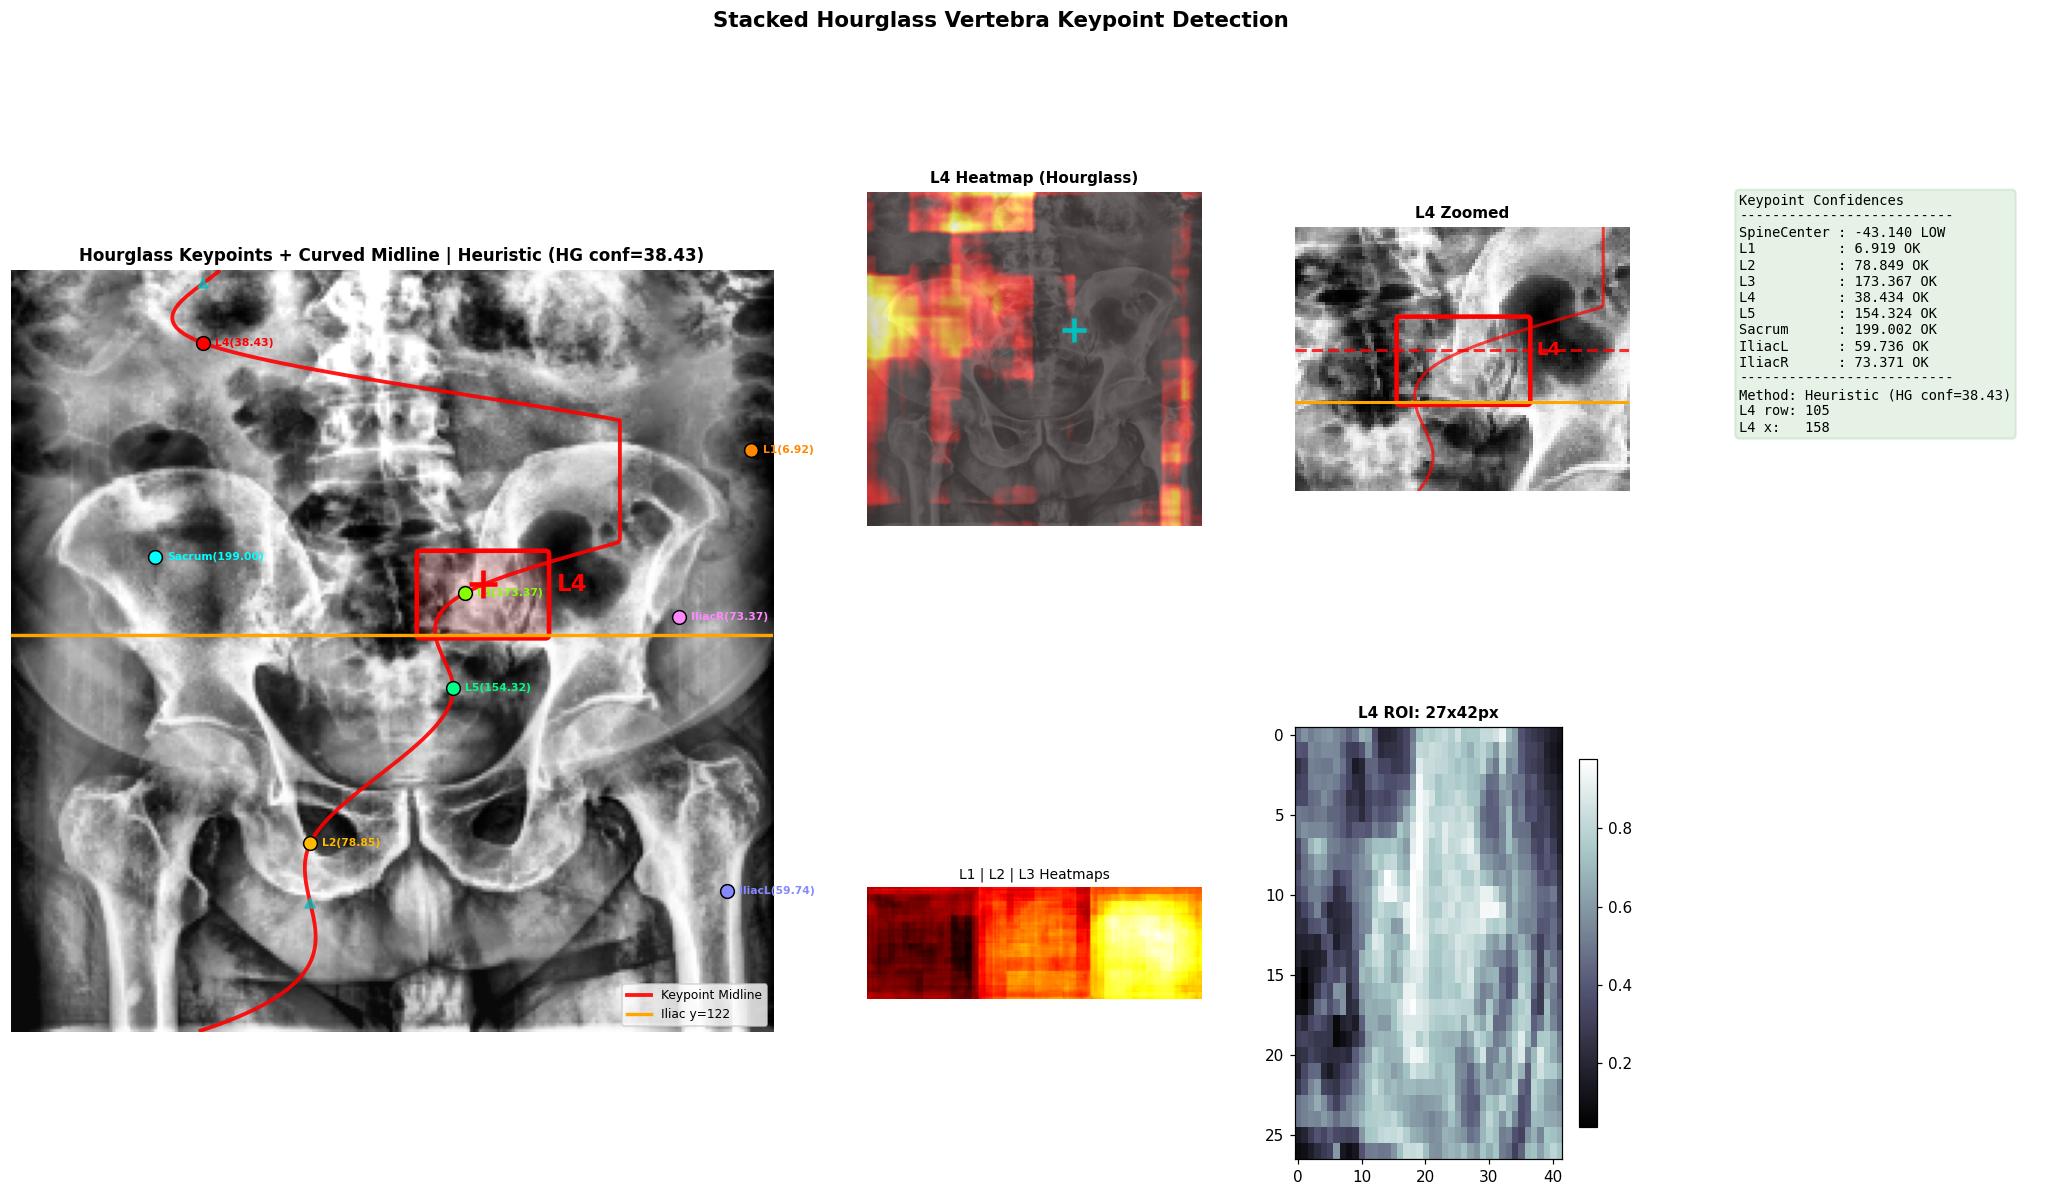

L4 ROI: (27, 42)


In [10]:
def draw_hourglass_result(clahe, final_hm, coords_img, confs,
                           midline_x, anc_r, anc_xs,
                           iliac_row, l4_row, l4_sx,
                           t_l4, b_l4, l4_x1, l4_x2,
                           det_method, cfg=CFG, save_path=None):
    h,w   = clahe.shape
    HM    = cfg['hm_size']
    scale = cfg['img_size']/HM

    fig = plt.figure(figsize=(24,12))
    gs  = GridSpec(2,5,figure=fig,hspace=0.35,wspace=0.28)

    # ── 전체 이미지 + Keypoints + Midline ──
    ax = fig.add_subplot(gs[:,0:2])
    ax.imshow(clahe,cmap='gray')
    ax.plot(midline_x, np.arange(h), 'r-', lw=2.5, alpha=0.9, label='Keypoint Midline')
    # Anchor points (cubic spline 제어점)
    for ry,rx in zip(anc_r,anc_xs):
        ax.plot(rx,ry,'c^',ms=7,alpha=0.7,zorder=4)
    ax.axhline(iliac_row,color='#FFA500',lw=2.2,label=f'Iliac y={iliac_row}')
    # 각 keypoint 표시
    kp_colors = {0:'white',1:'#FF8800',2:'#FFBB00',3:'#88FF00',
                 4:'red',  5:'#00FF88',6:'#00FFFF',7:'#8888FF',8:'#FF88FF'}
    for ki,name in enumerate(KP_NAMES):
        ry,rx = coords_img[ki]
        c = float(confs[ki])
        if c >= 0.05 and 0<ry<h and 0<rx<w:
            ax.plot(rx,ry,'o',color=kp_colors[ki],ms=9,
                    markeredgecolor='black',markeredgewidth=1,zorder=5)
            ax.text(rx+4,ry,f'{name}({c:.2f})',fontsize=7,color=kp_colors[ki],
                    fontweight='bold',va='center')
    # L4 ROI
    rect  = mpatches.FancyBboxPatch((l4_x1,t_l4),l4_x2-l4_x1,b_l4-t_l4,
                boxstyle='round,pad=1.2',lw=3,edgecolor='red',facecolor='red',alpha=0.12)
    rect2 = mpatches.FancyBboxPatch((l4_x1,t_l4),l4_x2-l4_x1,b_l4-t_l4,
                boxstyle='round,pad=1.2',lw=3,edgecolor='red',facecolor='none')
    ax.add_patch(rect); ax.add_patch(rect2)
    ax.plot(l4_sx,l4_row,'r+',ms=18,mew=3,zorder=6)
    ax.text(l4_x2+4,l4_row,'L4',color='red',fontsize=15,fontweight='bold',va='center')
    ax.legend(fontsize=8,loc='lower right')
    ax.set_title(f'Hourglass Keypoints + Curved Midline | {det_method}',
                 fontsize=11,fontweight='bold')
    ax.axis('off')

    # ── L4 Heatmap (raw) ──
    ax = fig.add_subplot(gs[0,2])
    l4_hm_up = cv2.resize(final_hm[KP_L4_IDX],(h,h),interpolation=cv2.INTER_LINEAR)
    ax.imshow(clahe,cmap='gray',alpha=0.5)
    ax.imshow(l4_hm_up,cmap='hot',alpha=0.6,vmin=0,vmax=l4_hm_up.max())
    ax.plot(l4_sx,l4_row,'c+',ms=16,mew=3,zorder=5)
    ax.set_title('L4 Heatmap (Hourglass)',fontsize=10,fontweight='bold'); ax.axis('off')

    # ── All keypoint heatmaps (mosaic) ──
    ax = fig.add_subplot(gs[1,2])
    mosaic = np.zeros((HM,HM*3),dtype=np.float32)
    for i in range(3):
        mosaic[:,i*HM:(i+1)*HM] = final_hm[i+1]  # L1,L2,L3
    ax.imshow(mosaic,cmap='hot')
    ax.set_title('L1 | L2 | L3 Heatmaps',fontsize=9); ax.axis('off')

    # ── L4 확대 뷰 ──
    zy1=max(0,t_l4-30); zy2=min(h,b_l4+30)
    zx1=max(0,l4_sx-55); zx2=min(w,l4_sx+55)
    ax = fig.add_subplot(gs[0,3])
    ax.imshow(clahe[zy1:zy2,zx1:zx2],cmap='gray')
    rect3=mpatches.FancyBboxPatch((l4_x1-zx1,t_l4-zy1),l4_x2-l4_x1,b_l4-t_l4,
                boxstyle='round,pad=1',lw=3,edgecolor='red',facecolor='none')
    ax.add_patch(rect3)
    ax.plot(midline_x[zy1:zy2]-zx1,range(zy2-zy1),'r-',lw=2,alpha=0.7)
    ax.axhline(l4_row-zy1,color='red',lw=2,linestyle='--',alpha=0.8)
    ax.axhline(iliac_row-zy1,color='#FFA500',lw=2)
    ax.text(l4_x2-zx1+3,l4_row-zy1,'L4',color='red',fontsize=12,fontweight='bold',va='center')
    ax.set_title('L4 Zoomed',fontsize=10,fontweight='bold'); ax.axis('off')

    # ── L4 ROI ──
    l4_roi=clahe[t_l4:b_l4,l4_x1:l4_x2]
    ax = fig.add_subplot(gs[1,3])
    im=ax.imshow(l4_roi,cmap='bone',aspect='auto')
    plt.colorbar(im,ax=ax,shrink=0.85)
    ax.set_title(f'L4 ROI: {l4_roi.shape[0]}x{l4_roi.shape[1]}px',fontsize=10,fontweight='bold')

    # ── Confidence bar ──
    ax = fig.add_subplot(gs[:,4])
    ax.axis('off')
    conf_lines = ["Keypoint Confidences", "-"*26]
    for ki,name in enumerate(KP_NAMES):
        c = float(confs[ki])
        status = "OK" if c>=0.05 else "LOW"
        conf_lines.append(f"{name:12s}: {c:.3f} {status}")
    conf_lines += ["-"*26, f"Method: {det_method[:25]}",
                   f"L4 row: {l4_row}", f"L4 x:   {l4_sx}"]
    conf_text = "\n".join(conf_lines)

    color = 'green' if float(confs[KP_L4_IDX])>=0.05 else 'orange'
    ax.text(0.05,0.95,conf_text,transform=ax.transAxes,fontsize=9,
            va='top',fontfamily='monospace',
            bbox=dict(boxstyle='round',facecolor=color,alpha=0.1,edgecolor=color,lw=1.5))

    plt.suptitle('Stacked Hourglass Vertebra Keypoint Detection',
                 fontsize=14,fontweight='bold')
    if save_path: plt.savefig(save_path,dpi=130,bbox_inches='tight')
    plt.show()
    return l4_roi


l4_roi = draw_hourglass_result(
    clahe, final_hm, coords_img, confs,
    midline_x, anc_r, anc_xs,
    iliac_row, l4_row, l4_sx,
    t_l4, b_l4, l4_x1, l4_x2,
    det_method,
    save_path=f'{RESULT_DIR}/02_hourglass_l4.png')
print(f"L4 ROI: {l4_roi.shape}")


## Step 9: Phantom-free Calibration & BMD 측정

In [11]:
def phantom_free_calibration(clahe, midline_x, iliac_row, cfg=CFG):
    h,w=clahe.shape; sw=cfg['muscle_offset'][0]; ew=cfg['muscle_offset'][1]
    rm=cfg['muscle_rows_above']; r0m=max(0,iliac_row-rm); r1m=min(h,iliac_row+10)
    muscle_vals=[]
    for side in [1,-1]:
        for r in range(r0m,r1m):
            mx=int(np.clip(midline_x[r],ew,w-ew-1))
            x1=int(min(mx+side*sw,mx+side*ew)); x2=int(max(mx+side*sw,mx+side*ew))
            x1=max(0,x1); x2=min(w,x2)
            if x2>x1: muscle_vals.extend(clahe[r,x1:x2].tolist())
    mu=float(np.median(muscle_vals)) if muscle_vals else 0.5
    ms=float(np.std(muscle_vals))    if muscle_vals else 0.05
    air=np.concatenate([clahe[:15,:15].ravel(),clahe[:15,-15:].ravel()])
    return {'muscle_mean':mu,'muscle_std':ms,'air_mean':float(np.percentile(air,5)),
            'n_muscle_pixels':len(muscle_vals)}


def calibrated_bmd(l4_roi, calib, cfg=CFG):
    if l4_roi is None or l4_roi.size==0: return None
    flat=l4_roi.ravel(); lo,hi=np.percentile(flat,[10,90])
    core=flat[(flat>=lo)&(flat<=hi)]
    bm=float(np.mean(core)) if len(core)>0 else float(flat.mean())
    mu=calib['muscle_mean']
    bn=bm/mu if mu>1e-6 else bm
    ps=bn*cfg['ref_young_mean']
    ts=(ps-cfg['ref_young_mean'])/cfg['ref_young_std']
    zs=(ps-cfg['ref_age_mean'])  /cfg['ref_age_std']
    cr=(bm-mu)/max(calib['muscle_std'],0.01)
    tp=(bm*cfg['ref_young_mean']-cfg['ref_young_mean'])/cfg['ref_young_std']
    if   ts>=-1.0: who,risk,col="Normal",       "Low",     "#27ae60"
    elif ts>=-2.5: who,risk,col="Osteopenia",   "Moderate","#e67e22"
    else:          who,risk,col="Osteoporosis",  "High",    "#e74c3c"
    return {'bone_mean':bm,'muscle_mean':mu,'bone_norm':bn,'phantom_scale':ps,
            'ts_calibrated':ts,'zs_calibrated':zs,'ts_proxy':tp,'contrast_ratio':cr,
            'who':who,'risk':risk,'color':col}


# ── BMD 계산 ──
calib_info = phantom_free_calibration(clahe, midline_x, iliac_row)
bmd_result = calibrated_bmd(l4_roi, calib_info)

print("="*50)
print("  BMD Analysis Results")
print("="*50)
print(f"  Detection Method : {det_method}")
print(f"  Bone mean        : {bmd_result['bone_mean']:.4f}")
print(f"  Muscle mean      : {calib_info['muscle_mean']:.4f}")
print(f"  Bone/Muscle ratio: {bmd_result['bone_norm']:.4f}")
print(f"  T-Score (calib)  : {bmd_result['ts_calibrated']:+.2f}")
print(f"  T-Score (proxy)  : {bmd_result['ts_proxy']:+.2f}")
print(f"  WHO              : {bmd_result['who']}")
print(f"  Risk             : {bmd_result['risk']}")
print("="*50)


  BMD Analysis Results
  Detection Method : Heuristic (HG conf=38.43)
  Bone mean        : 0.5878
  Muscle mean      : 0.5864
  Bone/Muscle ratio: 1.0022
  T-Score (calib)  : +0.03
  T-Score (proxy)  : -5.36
  WHO              : Normal
  Risk             : Low


## Step 10: 완전 파이프라인 & 배치 처리

In [12]:
def full_pipeline_v4(path, hg_model_=None, cfg=CFG):
    """DICOM -> L4 BMD 완전 파이프라인 v4 (Hourglass)"""
    r={'status':'OK','filename':os.path.basename(path)}
    try:
        arr_d,meta,_  = load_dicom(path)
        _,clahe_d     = preprocess_xray(arr_d,cfg['img_size'])
        h_d,w_d       = clahe_d.shape

        model = hg_model_ or hg_model
        hm,coords,cf  = hourglass_predict(model,clahe_d,cfg)
        ml_x,ar,axs   = build_midline_from_keypoints(coords,cf,h_d,w_d,cfg)
        l4r,l4sx,tl4,bl4,x1,x2,il,mth = localize_l4_from_hg(
            coords,cf,ml_x,h_d,w_d,clahe_d,cfg)
        roi  = clahe_d[tl4:bl4,x1:x2]
        cal  = phantom_free_calibration(clahe_d,ml_x,il,cfg)
        bmd  = calibrated_bmd(roi,cal,cfg)

        r.update({'meta':meta,'clahe':clahe_d,'midline_x':ml_x,
                  'final_hm':hm,'coords_img':coords,'confs':cf,
                  'anchor_rows':ar,'anchor_xs':axs,
                  'iliac_row':il,'l4_row':l4r,'l4_sx':l4sx,
                  't_l4':tl4,'b_l4':bl4,'l4_x1':x1,'l4_x2':x2,
                  'l4_roi':roi,'calib':cal,'bmd':bmd,
                  'detection_method':mth})
    except Exception as e:
        import traceback; r['status']=f'ERROR: {e}'; r['tb']=traceback.format_exc()
    return r


def run_batch_v4(paths, model=None, save_dir=None):
    if save_dir: os.makedirs(save_dir,exist_ok=True)
    rows=[]
    for i,p in enumerate(tqdm(paths,desc='Batch v4',ncols=70)):
        r=full_pipeline_v4(p,model)
        row={'idx':i+1,'filename':os.path.basename(p),'status':r['status']}
        if r['status']=='OK':
            m=r['meta']; bmd=r['bmd']; cal=r['calib']
            if bmd:
                row.update({
                    'patient_id' :m['patient_id'],
                    'study_date' :m['study_date'],
                    'detection'  :r['detection_method'],
                    'l4_row'     :r['l4_row'],
                    'l4_x'       :r['l4_sx'],
                    'hg_l4_conf' :f"{float(r['confs'][KP_L4_IDX]):.3f}",
                    'bone_mean'  :f"{bmd['bone_mean']:.4f}",
                    'muscle_mean':f"{cal['muscle_mean']:.4f}",
                    'bone_norm'  :f"{bmd['bone_norm']:.4f}",
                    'ts_calib'   :f"{bmd['ts_calibrated']:+.3f}",
                    'ts_proxy'   :f"{bmd['ts_proxy']:+.3f}",
                    'z_score'    :f"{bmd['zs_calibrated']:+.3f}",
                    'who'        :bmd['who'],
                    'risk'       :bmd['risk'],
                })
        rows.append(row)

    df=pd.DataFrame(rows)
    csv_p=os.path.join(save_dir or '.','bmd_v4_report.csv')
    df.to_csv(csv_p,index=False)
    ok=df[df['status']=='OK']
    print(f"Batch: {len(rows)} | OK: {len(ok)}")
    if len(ok)>0 and 'ts_calib' in ok.columns:
        ts=ok['ts_calib'].astype(float)
        print(f"T-Score: mean={ts.mean():+.2f} min={ts.min():+.2f} max={ts.max():+.2f}")
        if 'detection' in ok.columns:
            for d,cnt in ok['detection'].value_counts().items():
                print(f"  {d[:40]:40s}: {cnt} ({cnt/len(ok)*100:.1f}%)")
    return df


# ── 실행 ──
files=list(set(
    glob.glob('./*.dcm')+glob.glob('./*.DCM')+
    glob.glob(os.path.join(DATASET_ROOT,'**','*.dcm'),recursive=True)))[:30]

if files:
    df=run_batch_v4(files, hg_model, save_dir=f'{RESULT_DIR}/batch')
    print(df[['filename','ts_calib','who','hg_l4_conf','detection']].to_string())
else:
    df=run_batch_v4([DICOM_FILE], hg_model, save_dir=f'{RESULT_DIR}/batch')
    print(df.to_string())


Batch v4: 100%|█████████████████████████| 1/1 [00:00<00:00, 13.48it/s]

Batch: 1 | OK: 1
T-Score: mean=+0.03 min=+0.03 max=+0.03
  Heuristic (HG conf=38.43)               : 1 (100.0%)
   idx                                                                filename status patient_id study_date                  detection  l4_row  l4_x hg_l4_conf bone_mean muscle_mean bone_norm ts_calib ts_proxy z_score     who risk
0    1  1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm     OK         75             Heuristic (HG conf=38.43)     105   158     38.434    0.5878      0.5864    1.0022   +0.029   -5.359  +0.522  Normal  Low


## Step 11: 점진적 학습 (Bootstrap & Active Learning)

샘플이 쌓일수록 모델 정확도를 높이는 방법입니다.


In [13]:
def progressive_training_pipeline(dataset_root, hg_model_, cfg=CFG,
                                   confidence_thresh=0.3):
    """\n    점진적 학습 파이프라인\n\n    Stage 1: 신뢰도 높은 케이스 (bright spine) 로 초기 학습\n    Stage 2: 학습된 모델로 어려운 케이스 pseudo-label 생성\n    Stage 3: 전체 데이터로 재학습\n    Stage 4: (반복) 수렴까지\n\n    confidence_thresh: Hourglass L4 confidence 임계값\n    - 높으면 더 확실한 케이스만 사용 (정확하지만 느림)\n    - 낮으면 더 많은 케이스 활용 (빠르지만 잡음 가능)\n    """
    def gdcm(d):
        return list(set(
            glob.glob(os.path.join(d,'*.dcm'))+
            glob.glob(os.path.join(d,'**','*.dcm'),recursive=True)))

    all_dcm = gdcm(dataset_root)
    if not all_dcm:
        print(f"No DICOM in {dataset_root}"); return

    print(f"Total DICOM: {len(all_dcm)}")

    # Stage 1: 품질 평가 -> 신뢰도별 분류
    print("\nStage 1: Quality Assessment...")
    high_q, low_q = [], []
    for p in tqdm(all_dcm[:50], desc='Quality check', ncols=70):
        try:
            arr,_,_ = load_dicom(p)
            _,cl    = preprocess_xray(arr,cfg['img_size'])
            qa      = assess_image_quality(cl)
            if qa['confidence'] >= 0.5: high_q.append(p)
            else:                        low_q.append(p)
        except: low_q.append(p)

    print(f"  High quality: {len(high_q)}, Low quality: {len(low_q)}")

    # Stage 2: 고품질 데이터로 초기 학습
    if len(high_q) >= 4:
        print(f"\nStage 2: Initial training on {len(high_q)} high-quality samples...")
        np.random.shuffle(high_q)
        n_tr = max(2, int(len(high_q)*0.8))
        tr   = high_q[:n_tr]; va = high_q[n_tr:]
        if not va: va = tr[:1]
        ds_tr = SpineKeypointDataset(tr,  augment=True,  cfg=cfg)
        ds_va = SpineKeypointDataset(va,  augment=False, cfg=cfg)
        dl_tr = DataLoader(ds_tr,batch_size=min(cfg['batch_size'],len(tr)),shuffle=True,num_workers=0)
        dl_va = DataLoader(ds_va,batch_size=1,shuffle=False,num_workers=0)
        stage2_cfg = {**cfg,'num_epochs':30,'early_stop':8}
        stage2_ckpt = f'{MODEL_DIR}/stage2_hourglass.pth'
        hist = train_hourglass(hg_model_, dl_tr, dl_va, stage2_cfg, stage2_ckpt)
        print(f"  Stage 2 done. Best L4-err: {min(hist['va_l4_err']):.1f}px")

    # Stage 3: 저품질 케이스 pseudo-label 생성 & 추가 학습
    if len(low_q) >= 2:
        print(f"\nStage 3: Bootstrap pseudo-labels for {len(low_q)} low-quality samples...")
        accepted = []
        for p in tqdm(low_q[:20], desc='Bootstrap', ncols=70):
            try:
                arr,_,_ = load_dicom(p); _,cl=preprocess_xray(arr,cfg['img_size'])
                _,coords,cf = hourglass_predict(hg_model_,cl,cfg)
                l4_conf = float(cf[KP_L4_IDX])
                if l4_conf >= confidence_thresh:
                    accepted.append(p)
            except: pass
        print(f"  Accepted with confidence>={confidence_thresh}: {len(accepted)}")

        if len(accepted) >= 2:
            all_train = (high_q + accepted)
            np.random.shuffle(all_train)
            n_tr = max(2, int(len(all_train)*0.8))
            tr2  = all_train[:n_tr]; va2 = all_train[n_tr:] or all_train[:1]
            ds_tr2 = SpineKeypointDataset(tr2,augment=True, cfg=cfg)
            ds_va2 = SpineKeypointDataset(va2,augment=False,cfg=cfg)
            dl_tr2 = DataLoader(ds_tr2,batch_size=cfg['batch_size'],shuffle=True,num_workers=0)
            dl_va2 = DataLoader(ds_va2,batch_size=1,shuffle=False,num_workers=0)
            stage3_cfg = {**cfg,'num_epochs':50,'lr':cfg['lr']*0.3,'early_stop':10}
            stage3_ckpt = f'{MODEL_DIR}/stage3_hourglass.pth'
            hist3 = train_hourglass(hg_model_, dl_tr2, dl_va2, stage3_cfg, stage3_ckpt)
            print(f"  Stage 3 done. Best L4-err: {min(hist3['va_l4_err']):.1f}px")
            return stage3_ckpt

    return None


print("Progressive training function defined.")
print()
print("실행 방법:")
print("  ckpt = progressive_training_pipeline(DATASET_ROOT, hg_model)")
print("  if ckpt:")
print("      hg_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))")
print()
print("데이터가 많을수록 Stage 3에서 어두운 척추 케이스도 잘 처리됩니다.")


Progressive training function defined.

실행 방법:
  ckpt = progressive_training_pipeline(DATASET_ROOT, hg_model)
  if ckpt:
      hg_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))

데이터가 많을수록 Stage 3에서 어두운 척추 케이스도 잘 처리됩니다.


## 부록: 수동 레이블 가이드 (정확도 최대화)

### JSON 레이블 형식

```json
{
  "filename": "patient_001.dcm",
  "keypoints": {
    "0": [32, 28],
    "1": [15, 27],
    "2": [22, 28],
    "3": [29, 28],
    "4": [36, 28],
    "5": [43, 28],
    "6": [50, 28],
    "7": [40, 18],
    "8": [40, 38]
  },
  "note": "heatmap coordinate (64x64 scale)"
}
```

키포인트 인덱스: `0=SpineCenter, 1=L1, 2=L2, 3=L3, 4=L4★, 5=L5, 6=Sacrum, 7=IliacL, 8=IliacR`

좌표: **heatmap 해상도(64x64)** 기준 `[y, x]`
이미지 좌표(256)를 4로 나누면 heatmap 좌표.

### 정확도 향상 로드맵

| 단계 | 데이터 수 | 예상 L4-err |
|---|---|---|
| Pseudo-label only | 0개 | ~20-40px |
| 10개 수동 레이블 | 10개 | ~10-20px |
| 50개 수동 레이블 | 50개 | ~5-10px |
| 100개+ | 100개+ | <5px |

**10개만 정확히 레이블해도 어두운 척추 케이스 대폭 개선됩니다.**
